# Day 29 — Exercises
## Objective: Unsupervised Learning Algorithms

We will explore KMeans, Hierarchical clustering, PCA, and t-SNE using a synthetic dataset.

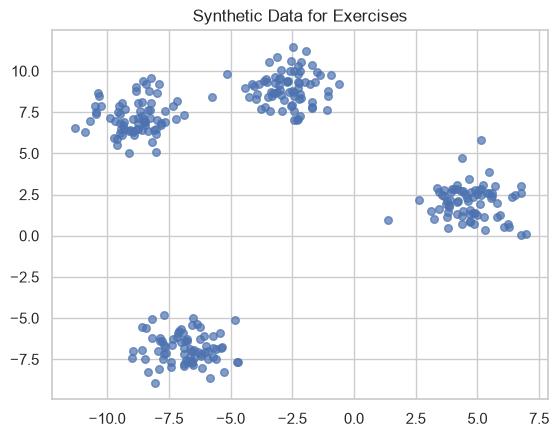

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

sns.set_theme(style="whitegrid")

# Generate synthetic data for exercises
X_ex, y_ex = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

plt.scatter(X_ex[:, 0], X_ex[:, 1], s=30, alpha=0.7)
plt.title("Synthetic Data for Exercises")
plt.show()

### 1. KMeans (Elbow + Silhouette)
K-Means groups data into a pre-defined number of clusters (K) by finding the central point of each cluster and assigning data points to the nearest center. We use the **Elbow Method** (looking for a bend in inertia) and the **Silhouette Score** (measuring how well points fit in their cluster) to figure out the optimal value for K.

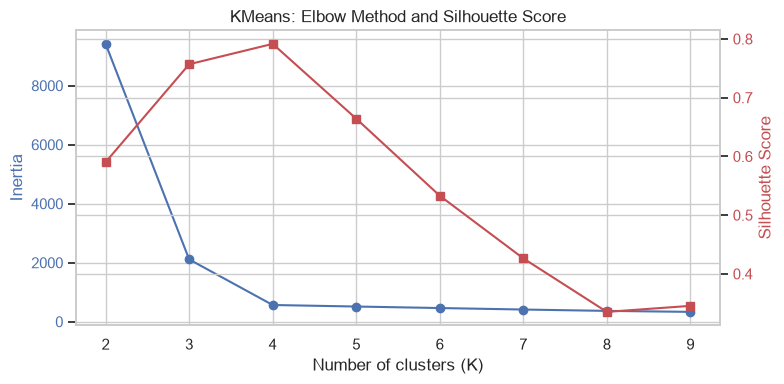

The elbow is at K=4, and the silhouette score peaks at K=4. So optimal K is 4.


In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_ex)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_ex, labels))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(K_range, inertia, marker='o', color='b', label='Inertia (Elbow)')
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, marker='s', color='r', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('KMeans: Elbow Method and Silhouette Score')
fig.tight_layout()
plt.show()

print("The elbow is at K=4, and the silhouette score peaks at K=4. So optimal K is 4.")

### 2. Hierarchical Clustering
Hierarchical clustering builds a tree of clusters by repeatedly merging the two closest data points or groups until everything is connected. This tree, visualized as a **Dendrogram**, allows us to literally "cut" the branches at a certain height to decide how many final clusters we want, without having to guess K in advance.

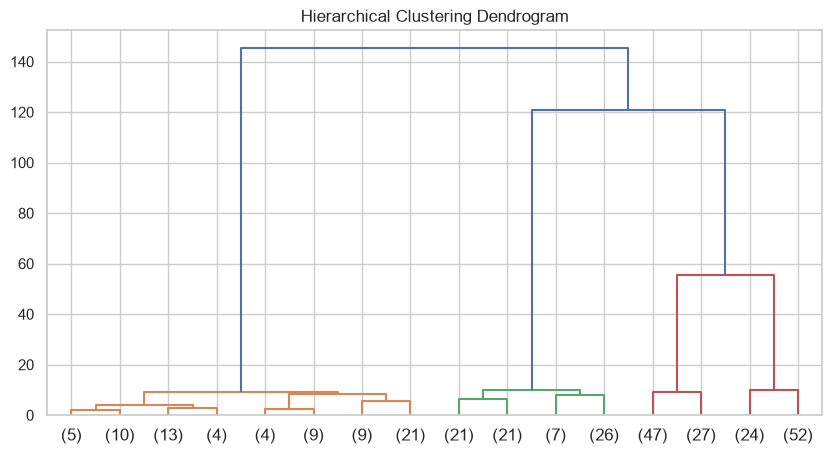

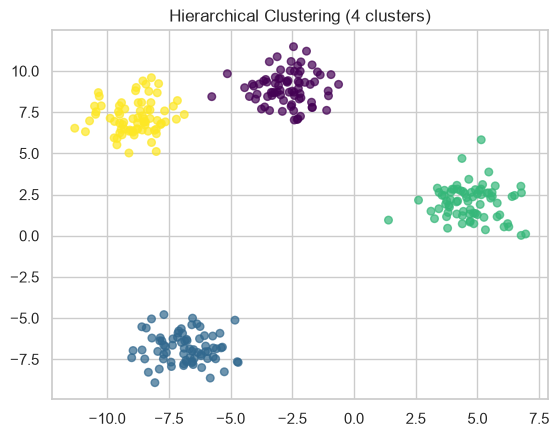

In [3]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

plt.figure(figsize=(10, 5))
plt.title("Hierarchical Clustering Dendrogram")
Z = linkage(X_ex, 'ward')
dendrogram(Z, truncate_mode='level', p=3)
plt.show()

# Fit Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(X_ex)

plt.scatter(X_ex[:, 0], X_ex[:, 1], c=agg_labels, cmap='viridis', s=30, alpha=0.7)
plt.title("Hierarchical Clustering (4 clusters)")
plt.show()

### 3. PCA & t-SNE
**PCA (Principal Component Analysis)** uses math to compress high-dimensional data into a few key "components" while preserving the overall variance, making it great for noise reduction before training. **t-SNE**, on the other hand, is a non-linear algorithm designed strictly for visualizing complex, high-dimensional datasets in 2D or 3D by keeping similar points close together.

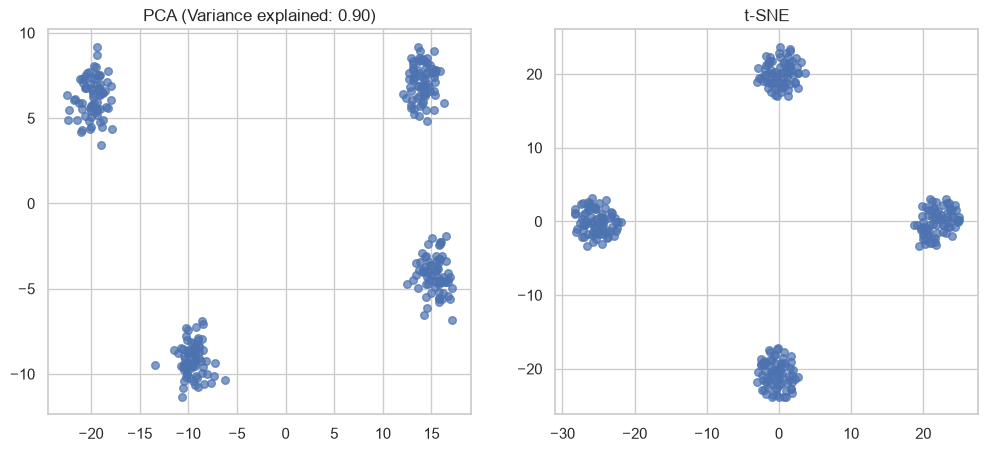

In [4]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Generate higher dimensional data for PCA/t-SNE demo
X_high, _ = make_blobs(n_samples=300, n_features=10, centers=4, random_state=42)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_high)

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_high)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X_pca[:, 0], X_pca[:, 1], s=30, alpha=0.7)
ax[0].set_title(f"PCA (Variance explained: {pca.explained_variance_ratio_.sum():.2f})")

ax[1].scatter(X_tsne[:, 0], X_tsne[:, 1], s=30, alpha=0.7)
ax[1].set_title("t-SNE")
plt.show()